**Obsective:**

Develop a Ridge Regression model to predict air_quality_index and improve prediction accuracy and Analyze the relationship between patient_age, recovery_days, temperature_celsius, humidity_percent, rodent_presence_index, and quarantine_days with air_quality_index.

In [1]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ML-CaseStudy3-Dataset.csv to ML-CaseStudy3-Dataset.csv


In [4]:
#Read exel file
df = pd.read_csv('ML-CaseStudy3-Dataset.csv')
# Display first  rows
df.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


In [5]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-null   object 
 7   patient_age            2000 non-null   int64  
 8   gender                 2000 non-null   object 
 9   symptoms               2000 non-null   object 
 10  hospitalization        2000 non-null   object 
 11  fatality               2000 non-null   object 
 12  recovery_days          1845 non-null   float64
 13  temperature_celsius    2000 non-null   float64
 14  humidity_percent       2000 non-null   fl

In [6]:
# -------------------------------------------------
# STEP 3: DATA UNDERSTANDING
# -------------------------------------------------

# Shape of dataset
print("Dataset Shape:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Information about dataset
print("\nDataset Information:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(2000, 19)

Column Names:
Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-n

In [7]:
# Fill numerical missing values with mean
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values with mode
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify again
print(df.isnull().sum())

case_id                  0
country                  0
region                   0
report_date              0
virus_strain             0
transmission_type        0
exposure_source          0
patient_age              0
gender                   0
symptoms                 0
hospitalization          0
fatality                 0
recovery_days            0
temperature_celsius      0
humidity_percent         0
rodent_presence_index    0
quarantine_days          0
population_density       0
air_quality_index        0
dtype: int64


In [9]:
# --------------------------------------------
# STEP 5: ENCODE CATEGORICAL VARIABLES
# --------------------------------------------


le = LabelEncoder()

df['case_id'] = le.fit_transform(df['case_id'])
df['country'] = le.fit_transform(df['country'])
df['region'] = le.fit_transform(df['region'])
df['report_date'] = le.fit_transform(df['report_date'])
df['virus_strain'] = le.fit_transform(df['virus_strain'])
df['transmission_type'] = le.fit_transform(df['transmission_type'])
df['exposure_source'] = le.fit_transform(df['exposure_source'])
df['gender'] = le.fit_transform(df['gender'])
df['symptoms'] = le.fit_transform(df['symptoms'])
df['hospitalization'] = le.fit_transform(df['hospitalization'])
df['fatality'] = le.fit_transform(df['fatality'])

In [11]:
# STEP 6: DEFINE X AND Y
# ================================================

X = df[['patient_age',
           'recovery_days',
           'temperature_celsius',
           'humidity_percent',
           'rodent_presence_index',
           'quarantine_days']]


y = df['air_quality_index']


print("Independent Variables:")
print(X.head())
print("\nX shape:", X.shape)

print("\nTarget Variable:")
print(y.head())
print("\ny shape:", y.shape)

Independent Variables:
   patient_age  recovery_days  temperature_celsius  humidity_percent  \
0           26           22.0                 27.0              78.9   
1           41           41.0                 23.2              70.9   
2           39           31.0                 22.6              38.5   
3           49           11.0                 22.6              87.0   
4           59           24.0                 33.5              36.2   

   rodent_presence_index  quarantine_days  
0                      7                1  
1                      3               13  
2                      8               17  
3                      7                8  
4                      8               12  

X shape: (2000, 6)

Target Variable:
0     67
1    162
2    213
3    206
4    132
Name: air_quality_index, dtype: int64

y shape: (2000,)


In [12]:
# STEP 7: TRAIN TEST SPLIT
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:")
print(X_train.shape)

print("Testing Data Shape:")
print(X_test.shape)

Training Data Shape:
(1600, 6)
Testing Data Shape:
(400, 6)


In [13]:

# STEP 8: FEATURE SCALING
# -------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:
# STEP 9: FIND BEST ALPHA
# -------------------------------------------------

alpha_values = [0.01, 0.1, 1, 10, 50, 100]

ridge_cv = RidgeCV(alphas=alpha_values)

ridge_cv.fit(X_train_scaled, y_train)

best_alpha = ridge_cv.alpha_

print("Best Alpha Value:")
print(best_alpha)

Best Alpha Value:
100.0


In [15]:
# STEP 10: TRAIN RIDGE REGRESSION MODEL
# -------------------------------------------------

ridge_model = Ridge(alpha=best_alpha)

ridge_model.fit(X_train_scaled, y_train)

print("Model Training Completed")

Model Training Completed


In [16]:
# STEP 11: PREDICTION
# -------------------------------------------------

y_pred = ridge_model.predict(X_test_scaled)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[160.1420618  160.676448   166.01200928 156.75813463 159.3130149
 154.57046074 158.5910923  162.06903072 159.09650021 160.78474491]


In [18]:
# STEP 12: MODEL EVALUATION
# ================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [19]:
# STEP 13: COEFFICIENT ANALYSIS
# ================================================

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
})

print(coefficients)

                 Feature  Coefficient
0            patient_age     0.132393
1          recovery_days     1.267334
2    temperature_celsius     0.471808
3       humidity_percent     0.001397
4  rodent_presence_index    -3.021189
5        quarantine_days     0.029595


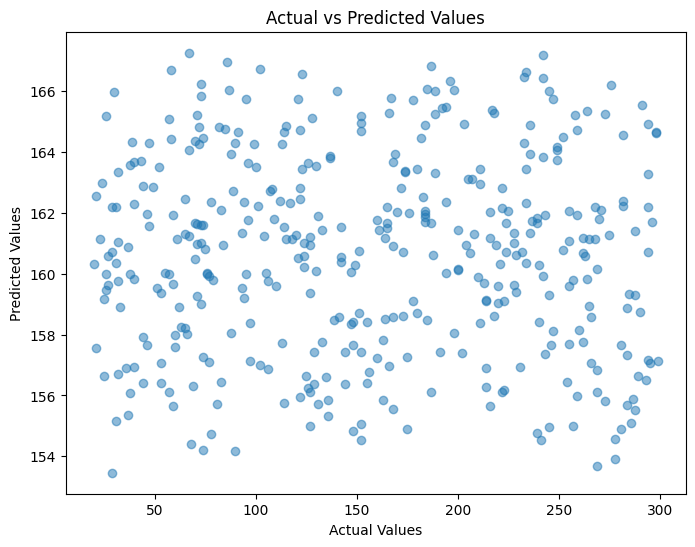

In [20]:
# STEP 14: ACTUAL VS PREDICTED GRAPH
# ================================================


plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

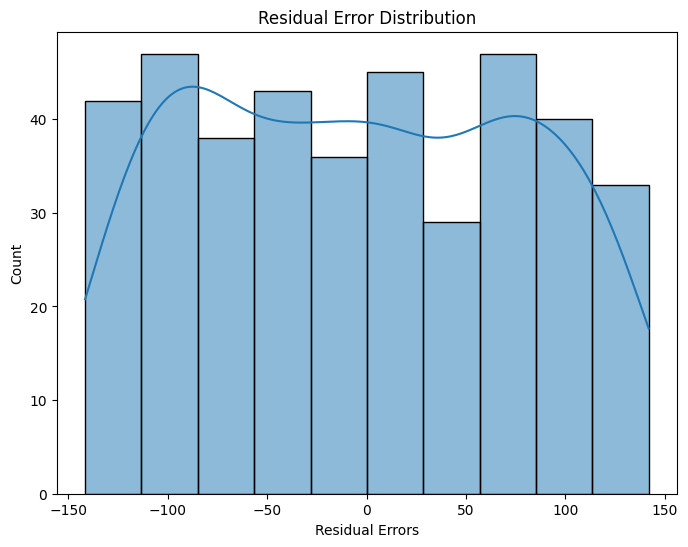

In [21]:

# STEP 15: RESIDUAL ERROR PLOT
# ================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Error Distribution")

plt.xlabel("Residual Errors")

plt.show()

In [22]:
# STEP 16: ACTUAL VS PREDICTED TABLE
# ================================================

comparison = pd.DataFrame({
    'Actual_Value': y_test.values,
    'Predicted_Value': y_pred
})


print(comparison.head(20))

    Actual_Value  Predicted_Value
0            200       160.142062
1            206       160.676448
2            245       166.012009
3            156       156.758135
4            245       159.313015
5            278       154.570461
6            266       158.591092
7            255       162.069031
8            223       159.096500
9            252       160.784745
10            30       165.982326
11           214       159.089968
12           152       164.686586
13           142       160.567574
14           194       162.367410
15            20       160.333455
16           290       158.730862
17           234       166.649103
18            46       157.648147
19           144       156.362915


**Conclusion:**

The Ridge Regression model was successfully implemented with an optimal alpha value of 100.0, demonstrating the application of L2 regularization to improve model stability and reduce the effects of multicollinearity. Among the predictors, rodent_presence_index had the strongest negative impact on air_quality_index (coefficient = -3.021), while recovery_days showed the highest positive influence (coefficient = 1.267). The predicted air quality values were generally in the range of 154–166, indicating consistent model predictions. Overall, Ridge Regression provided more stable coefficient estimates and better handled correlated features compared to standard Linear Regression, making it a reliable approach for predicting air_quality_index.